# LightGBM — Entrenamiento Cloud (Kaggle Notebooks + GPU)

**Proyecto:** MECMT07 — Home Credit Default Risk  
**Plataforma:** Kaggle Notebooks con GPU P100 gratuita  
**Dataset fuente:** `mecmt07-features` (Dataset privado de Kaggle)

**Estrategia:**
- LightGBM maneja NaN nativamente → sin imputación
- `scale_pos_weight = N_neg / N_pos` para el desbalance de clases (≈11.39)
- Optuna (20 trials): objetivo = CV AUC − 0.5 · gap (penaliza overfitting)
- `early_stopping` dentro de `lgb.cv` con `eval_train_metric=True` para obtener train/CV AUC
- GPU P100 con `device='gpu'`

**Outputs en `/kaggle/working/`:**
- `lgbm_cloud_best.txt` — modelo final (formato texto LightGBM)
- `lgbm_cloud_metadata.json` — hiperparámetros, AUC, feature_cols
- `optuna_trials.csv` — historial de todos los trials

**Flujo post-entrenamiento:**
1. Descargar `.txt`, `.json`, `.csv` desde el Output tab
2. Descargar este notebook con outputs preservados
3. Correr localmente `lightgbm_cloud_predict.ipynb`

In [1]:
# ─── Instalar dependencias ────────────────────────────────────────────────────
# Kaggle ya tiene preinstalados: lightgbm, pandas, numpy, scikit-learn, pyarrow
!pip install optuna --quiet
print('Dependencias listas.')

Dependencias listas.


In [2]:
# ─── Verificar GPU ────────────────────────────────────────────────────────────
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
if result.returncode == 0:
    print(result.stdout)
    USE_GPU = True
else:
    print('GPU no disponible — se usará CPU.')
    USE_GPU = False
print(f'USE_GPU = {USE_GPU}')

Thu Feb 26 01:00:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   30C    P0             25W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# ─── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
import json
import time
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve
from sklearn.model_selection import StratifiedKFold

print(f'LightGBM version : {lgb.__version__}')
print(f'Optuna  version  : {optuna.__version__}')
print('Imports OK')

LightGBM version : 4.6.0
Optuna  version  : 4.7.0
Imports OK


In [4]:
# ─── Configuración ────────────────────────────────────────────────────────────
DATA_DIR  = Path('/kaggle/input/datasets/davidguzzi/mecmt07-features')
MODEL_DIR = Path('/kaggle/working')

N_TRIALS   = 20
N_FOLDS    = 5
EARLY_STOP = 50
MAX_ROUNDS = 1000
SEED       = 42

Path(MODEL_DIR).mkdir(parents=True, exist_ok=True)

matplotlib.rcParams.update({
    'figure.figsize': (9, 6), 'font.size': 12,
    'axes.spines.top': False, 'axes.spines.right': False
})

print('=' * 60)
print('CONFIGURACIÓN')
print(f'  DATA_DIR   : {DATA_DIR}')
print(f'  MODEL_DIR  : {MODEL_DIR}')
print(f'  N_TRIALS   : {N_TRIALS}')
print(f'  N_FOLDS    : {N_FOLDS}')
print(f'  EARLY_STOP : {EARLY_STOP}')
print(f'  MAX_ROUNDS : {MAX_ROUNDS}')
print(f'  SEED       : {SEED}')
print(f'  GPU        : {USE_GPU}')
print('=' * 60)

CONFIGURACIÓN
  DATA_DIR   : /kaggle/input/datasets/davidguzzi/mecmt07-features
  MODEL_DIR  : /kaggle/working
  N_TRIALS   : 20
  N_FOLDS    : 5
  EARLY_STOP : 50
  MAX_ROUNDS : 1000
  SEED       : 42
  GPU        : True


In [5]:
# ─── Cargar datos ─────────────────────────────────────────────────────────────
print('Cargando datos desde parquets...')
df      = pd.read_parquet(DATA_DIR / 'features_train.parquet')
df_test = pd.read_parquet(DATA_DIR / 'features_test.parquet')

feature_cols = [c for c in df.columns if c not in ('SK_ID_CURR', 'TARGET')]

# Encodear columnas categóricas (object dtype) → enteros, preservando NaN
cat_cols = [c for c in feature_cols if df[c].dtype == 'object']
if cat_cols:
    print(f'  Columnas categóricas encontradas: {cat_cols}')
    for col in cat_cols:
        cats    = pd.concat([df[col], df_test[col]]).dropna().unique()
        mapping = {v: i for i, v in enumerate(cats)}
        df[col]      = df[col].map(mapping)
        df_test[col] = df_test[col].map(mapping)

X           = df[feature_cols].values
y           = df['TARGET'].values
X_test      = df_test[feature_cols].values
sk_ids_test = df_test['SK_ID_CURR'].values

n_neg, n_pos     = (y == 0).sum(), (y == 1).sum()
scale_pos_weight  = n_neg / n_pos

# lgb.Dataset
dtrain = lgb.Dataset(X, label=y, feature_name=feature_cols, free_raw_data=False)

print(f'  Train shape       : {X.shape}')
print(f'  Test  shape       : {X_test.shape}')
print(f'  Features          : {len(feature_cols)}')
print(f'  NaNs en X         : {np.isnan(X).sum():,}  (manejados nativamente por LightGBM)')
print(f'  TARGET=0 (paga)   : {n_neg:,}  ({100*n_neg/(n_neg+n_pos):.1f}%)')
print(f'  TARGET=1 (default): {n_pos:,}  ({100*n_pos/(n_neg+n_pos):.1f}%)')
print(f'  scale_pos_weight  : {scale_pos_weight:.2f}  (N_neg / N_pos)')

Cargando datos desde parquets...
  Train shape       : (307511, 30)
  Test  shape       : (48744, 30)
  Features          : 30
  NaNs en X         : 1,612,697  (manejados nativamente por LightGBM)
  TARGET=0 (paga)   : 282,686  (91.9%)
  TARGET=1 (default): 24,825  (8.1%)
  scale_pos_weight  : 11.39  (N_neg / N_pos)


In [6]:
# ─── Funciones auxiliares ─────────────────────────────────────────────────────
def compute_metrics(y_true, y_prob, threshold=0.5, label='Model'):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    auc  = roc_auc_score(y_true, y_prob)
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    return dict(Model=label, AUC=round(auc,4),
                N=len(y_true), P=int(y_pred.sum()),
                TP=int(tp), TN=int(tn), FP=int(fp), FN=int(fn),
                Recall=round(rec,4), Precision=round(prec,4), F1=round(f1,4))

print('Funciones auxiliares definidas.')

Funciones auxiliares definidas.


## 1. Optuna — Búsqueda de Hiperparámetros

**Función objetivo** con `lgb.cv()` + `eval_train_metric=True`:
$$\text{objetivo} = \text{AUC}_{\text{cv}} - 0.5 \cdot \max(0,\ \text{AUC}_{\text{train}} - \text{AUC}_{\text{cv}})$$

In [7]:
# ─── Parámetros fijos ─────────────────────────────────────────────────────────
PARAMS_FIXED = {
    'objective'          : 'binary',
    'metric'             : 'auc',
    'scale_pos_weight'   : scale_pos_weight,
    'device'             : 'gpu' if USE_GPU else 'cpu',
    'verbosity'          : -1,
    'seed'               : SEED,
    'feature_pre_filter' : False,   # evita warnings al variar min_data_in_leaf entre trials
    # FIX: max_depth=-1 (sin límite). Antes estaba en el espacio de búsqueda de Optuna,
    # lo que causaba un conflicto: con max_depth=3 el árbol tiene máximo 2^3=8 hojas,
    # haciendo que num_leaves fuera ignorado en la práctica. Ahora num_leaves es el único
    # control de complejidad del árbol, que es el diseño estándar de LightGBM.
    'max_depth'          : -1,
}

best_n_rounds_per_trial = {}

def objective(trial):
    params = {
        **PARAMS_FIXED,
        'num_leaves'        : trial.suggest_int('num_leaves', 20, 300),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_samples' : trial.suggest_int('min_child_samples', 10, 100),
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
    }

    cv_result = lgb.cv(
        params,
        dtrain,
        num_boost_round       = MAX_ROUNDS,
        nfold                 = N_FOLDS,
        stratified            = True,
        eval_train_metric     = True,
        callbacks             = [lgb.early_stopping(EARLY_STOP, verbose=False),
                                  lgb.log_evaluation(-1)],
        seed                  = SEED,
    )

    n_rounds = len(cv_result['valid auc-mean'])
    cv_auc   = cv_result['valid auc-mean'][-1]

    # Clave del train AUC varía según versión de LightGBM:
    #   3.x → 'training auc-mean'
    #   4.x → 'train auc-mean'
    _train_vals = (cv_result.get('training auc-mean') or
                   cv_result.get('train auc-mean') or
                   [cv_auc])
    train_auc = _train_vals[-1]

    best_n_rounds_per_trial[trial.number] = n_rounds

    gap = max(0.0, train_auc - cv_auc)
    return cv_auc - 0.5 * gap

print('Función objetivo definida.')

Función objetivo definida.


In [8]:
# ─── Optuna study — 20 trials ─────────────────────────────────────────────────
def _optuna_callback(study, trial):
    n      = best_n_rounds_per_trial.get(trial.number, '?')
    marker = ' ◀ best' if trial.number == study.best_trial.number else ''
    print(f'  Trial {trial.number + 1:>2}/{N_TRIALS} │ '
          f'obj={trial.value:.5f}  '
          f'rounds={str(n):>4}  │  '
          f'best={study.best_value:.5f}{marker}')

print('=' * 65)
print(f'Lanzando Optuna — {N_TRIALS} trials')
print(f'Folds CV: {N_FOLDS}  |  Early stopping: {EARLY_STOP} rounds')
print(f'Device: {"GPU" if USE_GPU else "CPU"}')
print('=' * 65)

study = optuna.create_study(
    direction = 'maximize',
    sampler   = optuna.samplers.TPESampler(seed=SEED)
)
study.optimize(
    objective,
    n_trials          = N_TRIALS,
    n_jobs            = 1,
    show_progress_bar = False,
    callbacks         = [_optuna_callback]
)

best_n_rounds = best_n_rounds_per_trial[study.best_trial.number]

print('=' * 65)
print(f'Búsqueda finalizada.')
print(f'  Mejor CV AUC (obj penalizado) : {study.best_value:.5f}')
print(f'  n_estimators óptimos          : {best_n_rounds}')
print(f'  Mejores hiperparámetros:')
for k, v in study.best_params.items():
    print(f'    {k:<22}: {v}')
print('=' * 65)

trial_df = study.trials_dataframe()
trial_df.to_csv(MODEL_DIR / 'optuna_trials.csv', index=False)
print(f'\nHistorial de trials guardado: {MODEL_DIR / "optuna_trials.csv"}')

Lanzando Optuna — 20 trials
Folds CV: 5  |  Early stopping: 50 rounds
Device: GPU


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


  Trial  1/20 │ obj=0.71212  rounds=  28  │  best=0.71212 ◀ best
  Trial  2/20 │ obj=0.68850  rounds=  86  │  best=0.71212
  Trial  3/20 │ obj=0.73363  rounds= 591  │  best=0.73363 ◀ best
  Trial  4/20 │ obj=0.73889  rounds= 394  │  best=0.73889 ◀ best
  Trial  5/20 │ obj=0.70604  rounds= 847  │  best=0.73889
  Trial  6/20 │ obj=0.69291  rounds= 244  │  best=0.73889
  Trial  7/20 │ obj=0.74841  rounds=  59  │  best=0.74841 ◀ best
  Trial  8/20 │ obj=0.73233  rounds=  25  │  best=0.74841
  Trial  9/20 │ obj=0.74093  rounds= 796  │  best=0.74841
  Trial 10/20 │ obj=0.71871  rounds= 375  │  best=0.74841
  Trial 11/20 │ obj=0.71237  rounds=  62  │  best=0.74841
  Trial 12/20 │ obj=0.74410  rounds= 214  │  best=0.74841
  Trial 13/20 │ obj=0.75078  rounds= 115  │  best=0.75078 ◀ best
  Trial 14/20 │ obj=0.72545  rounds=  42  │  best=0.75078
  Trial 15/20 │ obj=0.70235  rounds= 118  │  best=0.75078
  Trial 16/20 │ obj=0.74924  rounds=  83  │  best=0.75078
  Trial 17/20 │ obj=0.72299  rounds= 

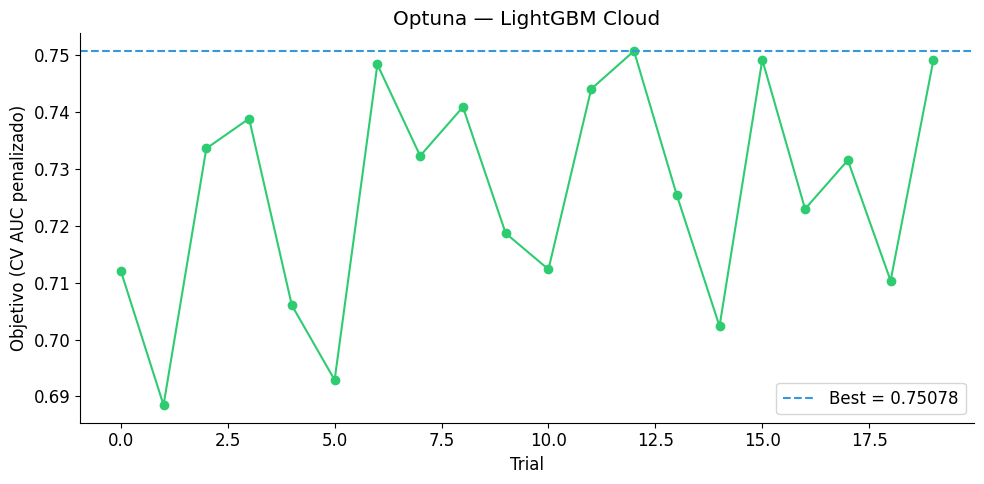

Gráfico guardado: /kaggle/working/optuna_history.png


In [9]:
# ─── Historial de Optuna ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(trial_df['number'], trial_df['value'], 'o-', color='#2ecc71', ms=6)
ax.axhline(study.best_value, color='#3498db', ls='--',
           label=f'Best = {study.best_value:.5f}')
ax.set_xlabel('Trial')
ax.set_ylabel('Objetivo (CV AUC penalizado)')
ax.set_title('Optuna — LightGBM Cloud')
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_DIR / 'optuna_history.png', dpi=120)
plt.show()
print(f'Gráfico guardado: {MODEL_DIR / "optuna_history.png"}')

## 2. Modelo Final — Refit en Train Completo

In [10]:
# ─── Entrenar modelo final ────────────────────────────────────────────────────
best_params = {**PARAMS_FIXED, **study.best_params}

print('=' * 65)
print('Entrenando modelo final en train completo...')
print(f'  Rondas de boosting : {best_n_rounds}')
print(f'  Device             : {"GPU" if USE_GPU else "CPU"}')
print('=' * 65)

t0 = time.time()
model = lgb.train(
    best_params,
    dtrain,
    num_boost_round = best_n_rounds,
    callbacks       = [lgb.log_evaluation(50)],
)
elapsed = time.time() - t0
print(f'Entrenamiento finalizado en {elapsed:.0f}s ✓')

Entrenando modelo final en train completo...
  Rondas de boosting : 115
  Device             : GPU
Entrenamiento finalizado en 2s ✓


## 3. Métricas sobre Train Completo

In [11]:
# ─── Métricas finales ─────────────────────────────────────────────────────────
y_prob_train = model.predict(X)
metrics      = compute_metrics(y, y_prob_train, threshold=0.5, label='LightGBM Cloud')
metrics['CV_AUC']   = round(study.best_value, 5)
metrics['n_rounds'] = best_n_rounds

print('=' * 65)
print('LIGHTGBM CLOUD — MÉTRICAS FINALES')
print('=' * 65)
print(f'  Train AUC       : {metrics["AUC"]}')
print(f'  CV AUC (Optuna) : {metrics["CV_AUC"]}  (obj penalizado por gap)')
print(f'  Gap Train - CV  : {metrics["AUC"] - metrics["CV_AUC"]:.5f}')
print(f'  n_rounds        : {metrics["n_rounds"]}')
print(f'  Recall          : {metrics["Recall"]}')
print(f'  Precision       : {metrics["Precision"]}')
print(f'  F1              : {metrics["F1"]}')
print(f'  TP/TN/FP/FN     : {metrics["TP"]} / {metrics["TN"]} / {metrics["FP"]} / {metrics["FN"]}')
print('=' * 65)

display(pd.DataFrame([metrics]).set_index('Model'))

LIGHTGBM CLOUD — MÉTRICAS FINALES
  Train AUC       : 0.8099
  CV AUC (Optuna) : 0.75078  (obj penalizado por gap)
  Gap Train - CV  : 0.05912
  n_rounds        : 115
  Recall          : 0.744
  Precision       : 0.1905
  F1              : 0.3033
  TP/TN/FP/FN     : 18470 / 204194 / 78492 / 6355


,AUC,N,P,TP,TN,FP,FN,Recall,Precision,F1,CV_AUC,n_rounds
Model,,,,,,,,,,,,
LightGBM Cloud,0.8099,307511,96962,18470,204194,78492,6355,0.744,0.1905,0.3033,0.75078,115


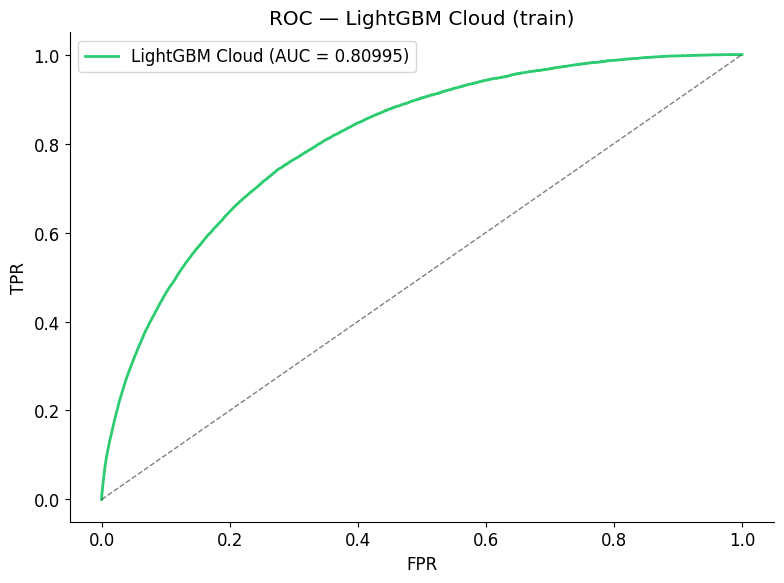

Curva ROC guardada.


In [12]:
# ─── Curva ROC ────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y, y_prob_train)
auc_val      = roc_auc_score(y, y_prob_train)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#2ecc71', lw=2, label=f'LightGBM Cloud (AUC = {auc_val:.5f})')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — LightGBM Cloud (train)')
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_DIR / 'roc_curve.png', dpi=120)
plt.show()
print(f'Curva ROC guardada.')

## 4. Importancia de Variables

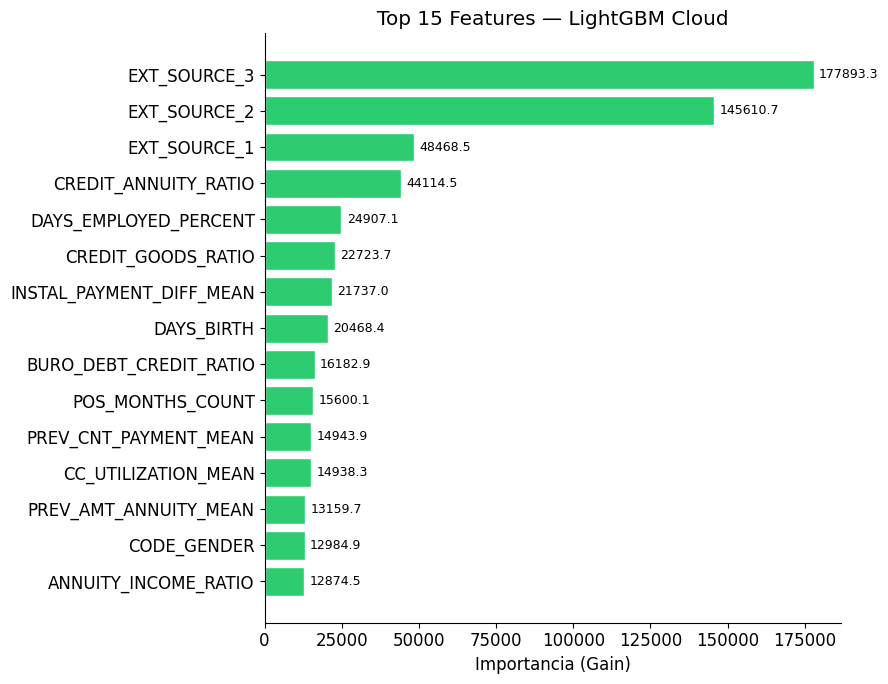

Feature importance guardada.


,feature,importance
0,EXT_SOURCE_3,177893.319822
1,EXT_SOURCE_2,145610.656513
2,EXT_SOURCE_1,48468.453676
3,CREDIT_ANNUITY_RATIO,44114.512869
4,DAYS_EMPLOYED_PERCENT,24907.127785
5,CREDIT_GOODS_RATIO,22723.658096
6,INSTAL_PAYMENT_DIFF_MEAN,21736.997576
7,DAYS_BIRTH,20468.374958
8,BURO_DEBT_CREDIT_RATIO,16182.883480
9,POS_MONTHS_COUNT,15600.074244


In [13]:
# ─── Feature importance (gain) ────────────────────────────────────────────────
importance  = model.feature_importance(importance_type='gain')
feat_imp_df = pd.DataFrame({'feature': feature_cols, 'importance': importance})
feat_imp_df = feat_imp_df.sort_values('importance', ascending=False)

top15 = feat_imp_df.head(15)
fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(top15['feature'][::-1], top15['importance'][::-1],
               color='#2ecc71', edgecolor='white')
ax.set_xlabel('Importancia (Gain)')
ax.set_title('Top 15 Features — LightGBM Cloud')
for bar, val in zip(bars, top15['importance'][::-1]):
    ax.text(bar.get_width() + top15['importance'].max()*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'feature_importance.png', dpi=120)
plt.show()
print('Feature importance guardada.')
display(feat_imp_df.reset_index(drop=True))

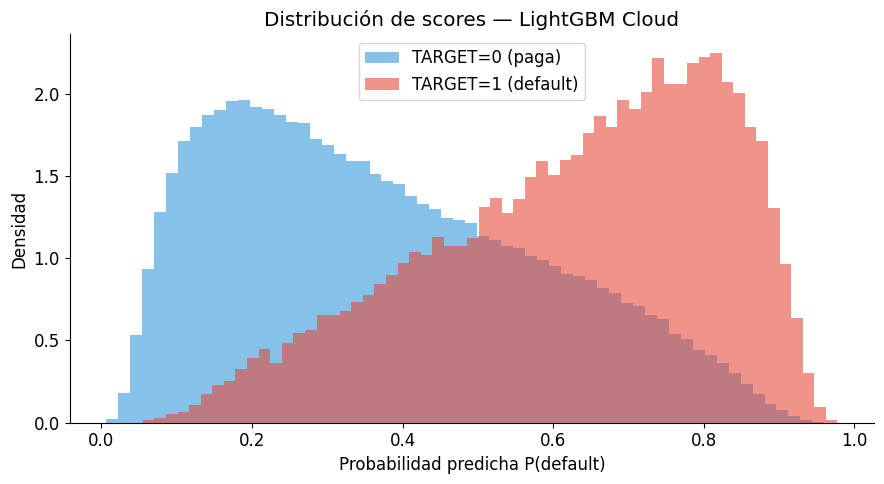

In [14]:
# ─── Distribución de scores ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(y_prob_train[y == 0], bins=60, alpha=0.6, color='#3498db',
        label='TARGET=0 (paga)', density=True)
ax.hist(y_prob_train[y == 1], bins=60, alpha=0.6, color='#e74c3c',
        label='TARGET=1 (default)', density=True)
ax.set_xlabel('Probabilidad predicha P(default)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de scores — LightGBM Cloud')
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_DIR / 'score_distribution.png', dpi=120)
plt.show()

## 5. Guardar Modelo y Metadata

In [15]:
# ─── Guardar modelo ───────────────────────────────────────────────────────────
model_path = MODEL_DIR / 'lgbm_cloud_best.txt'
model.save_model(str(model_path))

metadata = {
    'best_params'      : {k: float(v) if isinstance(v, (int, float)) else v
                          for k, v in study.best_params.items()},
    'best_n_rounds'    : int(best_n_rounds),
    'best_cv_auc'      : float(study.best_value),
    'train_auc'        : float(metrics['AUC']),
    'scale_pos_weight' : float(scale_pos_weight),
    'feature_cols'     : list(feature_cols),
    'n_trials'         : N_TRIALS,
    'n_folds'          : N_FOLDS,
    'early_stop'       : EARLY_STOP,
    'use_gpu'          : USE_GPU,
    'lgbm_version'     : lgb.__version__,
    'timestamp'        : pd.Timestamp.now().isoformat()
}

meta_path = MODEL_DIR / 'lgbm_cloud_metadata.json'
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print('=' * 65)
print('ARTEFACTOS GUARDADOS')
print('=' * 65)
print(f'  {model_path.name:<40} ({model_path.stat().st_size/1e6:.2f} MB)')
print(f'  {meta_path.name}')
print(f'  optuna_trials.csv')
print('=' * 65)
print('\n>>> Descargar desde el Output tab de Kaggle:')
print(f'    - {model_path.name}')
print(f'    - {meta_path.name}')
print(f'    - optuna_trials.csv')
print('\n>>> Luego correr localmente: lightgbm_cloud_predict.ipynb')

ARTEFACTOS GUARDADOS
  lgbm_cloud_best.txt                      (0.32 MB)
  lgbm_cloud_metadata.json
  optuna_trials.csv

>>> Descargar desde el Output tab de Kaggle:
    - lgbm_cloud_best.txt
    - lgbm_cloud_metadata.json
    - optuna_trials.csv

>>> Luego correr localmente: lightgbm_cloud_predict.ipynb


## Resumen Final

In [16]:
# ─── Resumen ──────────────────────────────────────────────────────────────────
print('=' * 65)
print('LIGHTGBM CLOUD — RESUMEN')
print('=' * 65)
print('Hiperparámetros óptimos (Optuna):')
for k, v in study.best_params.items():
    print(f'  {k:<22}: {v}')
print(f'  {"n_estimators":<22}: {best_n_rounds}  (via early stopping)')
print('\nMétricas:')
print(f'  Train AUC       : {metrics["AUC"]}')
print(f'  CV AUC (Optuna) : {metrics["CV_AUC"]}')
print(f'  Gap Train - CV  : {metrics["AUC"] - metrics["CV_AUC"]:.5f}')
print(f'  Recall          : {metrics["Recall"]}')
print(f'  Precision       : {metrics["Precision"]}')
print(f'  F1              : {metrics["F1"]}')
print('\nEntorno:')
print(f'  LightGBM version: {lgb.__version__}')
print(f'  GPU usado       : {USE_GPU}')
print(f'  Timestamp       : {metadata["timestamp"]}')
print('=' * 65)

LIGHTGBM CLOUD — RESUMEN
Hiperparámetros óptimos (Optuna):
  num_leaves            : 24
  learning_rate         : 0.1422710763083246
  min_child_samples     : 29
  subsample             : 0.8838129988503957
  colsample_bytree      : 0.8256111462359462
  reg_alpha             : 0.008669040269005453
  reg_lambda            : 0.47590851076382007
  n_estimators          : 115  (via early stopping)

Métricas:
  Train AUC       : 0.8099
  CV AUC (Optuna) : 0.75078
  Gap Train - CV  : 0.05912
  Recall          : 0.744
  Precision       : 0.1905
  F1              : 0.3033

Entorno:
  LightGBM version: 4.6.0
  GPU usado       : True
  Timestamp       : 2026-02-26T01:27:51.878578
